In [1]:
import os

# Esto le dice a Java que permita los accesos que están causando el error
os.environ['JDK_JAVA_OPTIONS'] = (
    "--add-opens=java.base/java.lang=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.invoke=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
    "--add-opens=java.base/java.io=ALL-UNNAMED "
    "--add-opens=java.base/java.net=ALL-UNNAMED "
    "--add-opens=java.base/java.nio=ALL-UNNAMED "
    "--add-opens=java.base/java.util=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED "
    "--add-opens=java.base/sun.security.action=ALL-UNNAMED "
    "--add-opens=java.base/sun.util.calendar=ALL-UNNAMED "
    "--add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED"
)

from pyspark.sql import SparkSession
# ... resto de tu código


In [2]:
import os
import sys

# 1. USAR JAVA 11 (La ruta estándar en Ubuntu/Codespaces)
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# 2. RUTA A TU CARPETA DE SPARK (Verificá que esta sea la ruta exacta)
os.environ["SPARK_HOME"] = "/workspaces/Capstone_ProjectDE1/M5_Batch/spark/spark-3.3.2-bin-hadoop3"

# 3. ACTUALIZAR PATH
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["SPARK_HOME"] + "/bin:" + os.environ["PATH"]

# 4. AÑADIR AL PATH DE PYTHON
sys.path.append(os.path.join(os.environ["SPARK_HOME"], "python"))

# BUSCAR EL ARCHIVO PY4J (Importante: el nombre exacto varía según la versión de Spark)
# Si bajaste la 3.3.2 del Zoomcamp, suele ser 0.10.9.5
sys.path.append(os.path.join(os.environ["SPARK_HOME"], "python/lib/py4j-0.10.9.5-src.zip"))

from pyspark.sql import SparkSession

# 5. CREAR SESIÓN
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("test") \
    .getOrCreate()

print("¡Spark configurado con éxito!")


NOTE: Picked up JDK_JAVA_OPTIONS: --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED
NOTE: Picked up JDK_JAVA_OPTIONS: --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-o

26/03/26 22:08:34 WARN Utils: Your hostname, codespaces-7b0544 resolves to a loopback address: 127.0.0.1; using 10.0.1.239 instead (on interface eth0)
26/03/26 22:08:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/26 22:08:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/26 22:08:37 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
¡Spark configurado con éxito!


In [5]:
#!pip install pyspark


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /usr/local/python/3.12.1/bin/python3 -m pip install --upgrade pip


In [3]:
# =========================
# 1. SETUP SPARK
# =========================

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CustomerSupportBatch") \
    .master("local[*]") \
    .getOrCreate()

# Usar la ruta completa desde la raíz del Codespace
df = spark.read.option("header", True) \
    .csv("/workspaces/Capstone_ProjectDE1/M5_Batch/data/raw/customer_support_tickets.csv")


df.write.mode("overwrite") \
    .parquet("data/lake/tickets")
spark

26/03/26 22:08:52 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [62]:
# =========================
# 1. LOAD DATA
# =========================
# 1. CARGAR DATOS CORRECTAMENTE ( paso 1)
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# Define solo las columnas principales para probar la lectura total
schema = StructType([
    StructField("Ticket ID", StringType(), True),
    StructField("Customer Name", StringType(), True),
    StructField("Customer Email", StringType(), True),
    StructField("Customer Age", StringType(), True),
    StructField("Customer Gender", StringType(), True),
    StructField("Product Purchased", StringType(), True),
    StructField("Date of Purchase", StringType(), True),
    StructField("Ticket Type", StringType(), True),
    StructField("Ticket Subject", StringType(), True),
    StructField("Ticket Description", StringType(), True),
    StructField("Ticket Status", StringType(), True),
    StructField("Resolution", StringType(), True),
    StructField("Ticket Priority", StringType(), True),
    StructField("Ticket Channel", StringType(), True),
    StructField("First Response Time", StringType(), True),
    StructField("Time to Resolution", StringType(), True),
    StructField("Customer Satisfaction Rating", StringType(), True)
])

df = spark.read \
    .option("header", "true") \
    .option("multiLine", "true") \
    .option("escape", "\"") \
    .option("quote", "\"") \
    .schema(schema) \
    .option("mode", "PERMISSIVE") \
    .option("inferSchema", "true") \
    .csv("/workspaces/Capstone_ProjectDE1/M5_Batch/data/raw/customer_support_tickets.csv")

# Verificá ahora
df.show(5, truncate=False)

# FORZAR CONTEO TOTAL (Para verificar si lee los ~8000 registros)
print(f"Total de filas leídas: {df.count()}")

+---------+-------------------+--------------------------+------------+---------------+-----------------+----------------+---------------+------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------+---------------------------------------------+---------------+--------------+-------------------+-------------------+----------------------------+
|Ticket ID|Customer Name      |Customer Email            |Customer Age|Customer Gender|Product Purchased|Date of Purchase|Ticket Type    |Ticket Subject          |Ticket Description                                                                                                                                                  

In [48]:
#1. Limpiar los nombres de las columnas (Paso 2)
from pyspark.sql.functions import col

# Normalizar: minúsculas y reemplazar espacios por guiones bajos
df_clean = df.select([col(c).alias(c.lower().replace(" ", "_")) for c in df.columns])

# Verificá que los nombres ahora sean 'ticket_id', 'customer_name', etc.
print(df_clean.columns)


['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating']


In [49]:
#2. Guardar en Parquet (Paso 3)
df_clean.write.mode("overwrite").parquet("data/lake/tickets_final")

In [50]:
#1_ingestion
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BatchIngestion") \
    .getOrCreate()

df = spark.read.option("header", True) \
    .csv("/workspaces/Capstone_ProjectDE1/M5_Batch/data/raw/customer_support_tickets.csv")

df.write.mode("overwrite") \
    .parquet("data/lake/tickets")

In [51]:
#2_transformation
from pyspark.sql.functions import col, to_timestamp

# 1. Leer el parquet inicial
df = spark.read.parquet("data/lake/tickets")

# 2. Limpiar nombres (Pone todo en minúscula y saca espacios)
df_clean = df.select(
    [col(c).alias(c.lower().replace(" ", "_")) for c in df.columns]
)

# 3. Transformar la columna de fecha REAL (Cambié created_at por date_of_purchase)
df_typed = df_clean.withColumn(
    "date_of_purchase", 
    to_timestamp("date_of_purchase")
)

# 4. Guardar
df_typed.write.mode("overwrite") \
    .parquet("data/lake/tickets_clean")

print("Transformación completada con éxito.")
df_typed.printSchema() # Para que veas los nombres finales


[Stage 102:>                                                        (0 + 1) / 1]

Transformación completada con éxito.
root
 |-- ticket_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- customer_email: string (nullable = true)
 |-- customer_age: string (nullable = true)
 |-- customer_gender: string (nullable = true)
 |-- product_purchased: string (nullable = true)
 |-- date_of_purchase: timestamp (nullable = true)
 |-- ticket_type: string (nullable = true)
 |-- ticket_subject: string (nullable = true)
 |-- ticket_description: string (nullable = true)
 |-- ticket_status: string (nullable = true)
 |-- resolution: string (nullable = true)
 |-- ticket_priority: string (nullable = true)
 |-- ticket_channel: string (nullable = true)
 |-- first_response_time: string (nullable = true)
 |-- time_to_resolution: string (nullable = true)
 |-- customer_satisfaction_rating: string (nullable = true)



In [52]:
# 3_analytics
from pyspark.sql import SparkSession

# 1. Leer el parquet ya transformado (el que tiene nombres en minúscula)
df = spark.read.parquet("data/lake/tickets_clean")

# 2. Crear la vista temporal para SQL
df.createOrReplaceTempView("tickets")

# 3. Consulta SQL corregida: Usamos 'ticket_status' en lugar de 'status'
result = spark.sql("""
    SELECT 
        ticket_status as status, 
        COUNT(*) as total
    FROM tickets
    GROUP BY ticket_status
""")

# 4. Mostrar el resultado por consola antes de guardar
result.show()

# 5. Guardar el resultado final
result.write.mode("overwrite") \
    .parquet("data/output/status_summary")

print("Analítica completada y guardada en data/output/status_summary")


+--------------------+-----+
|              status|total|
+--------------------+-----+
|                 1.0|   26|
| [ { ""product_na...|    1|
| you should The i...|    1|
| but there are no...|    5|
| 2023-06-01 11:58:41|    1|
|                 _id|    1|
|    ""answer"":""3""|    1|
| 2023-06-01 20:05:52|    1|
| 2023-06-01 19:17:44|    1|
|       how about now|    1|
| 2023-06-01 17:09:59|    1|
| but the issue pe...|   13|
| 2023-06-01 05:49:23|    1|
| hoping it would ...|   10|
| 2023-06-01 06:48:53|    1|
| 2023-06-01 17:00:57|    1|
| or by clicking I...|    1|
|           call them|    1|
| 2023-06-01 04:54:38|    1|
| and everyone who...|    1|
+--------------------+-----+
only showing top 20 rows

Analítica completada y guardada en data/output/status_summary


In [53]:
df_final = spark.read.parquet("data/output/status_summary")
df_final.show()

+--------------------+-----+
|              status|total|
+--------------------+-----+
|                 1.0|   26|
| [ { ""product_na...|    1|
| you should The i...|    1|
| but there are no...|    5|
| 2023-06-01 11:58:41|    1|
|                 _id|    1|
|    ""answer"":""3""|    1|
| 2023-06-01 20:05:52|    1|
| 2023-06-01 19:17:44|    1|
|       how about now|    1|
| 2023-06-01 17:09:59|    1|
| but the issue pe...|   13|
| 2023-06-01 05:49:23|    1|
| hoping it would ...|   10|
| 2023-06-01 06:48:53|    1|
| 2023-06-01 17:00:57|    1|
| or by clicking I...|    1|
|           call them|    1|
| 2023-06-01 04:54:38|    1|
| and everyone who...|    1|
+--------------------+-----+
only showing top 20 rows



In [21]:
!pip install matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 51.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 52.9 MB/s  0:00:00s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 53.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 57.5 MB/s  0:00:00s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 53.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]37m━━━━ 8/9 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /usr/local/python/3.12.1/bin/python3 -m pip install --upgrade pip


In [54]:
# 3_analytics (Actualizado)
# Cómo arreglar el gráfico (Paso final):
#Tenés que volver a ejecutar las celdas en este orden específico para limpiar la memoria:
#Celda de Ingesta (Paso 1): Asegurate de correr la que tiene multiLine=True y inferSchema=True.
#Celda de Transformación (Paso 2): Volvé a crear el df_clean.
#Celda de Analytics (Paso 3): Volvé a crear la vista temporal y el result. OJO: Agregá un filtro para que solo use estados válidos:
df_clean.createOrReplaceTempView("tickets")

result = spark.sql("""
    SELECT ticket_status as status, COUNT(*) as total
    FROM tickets
    WHERE ticket_status IN ('Open', 'Closed', 'Pending', 'Resolved')
    GROUP BY ticket_status
""")

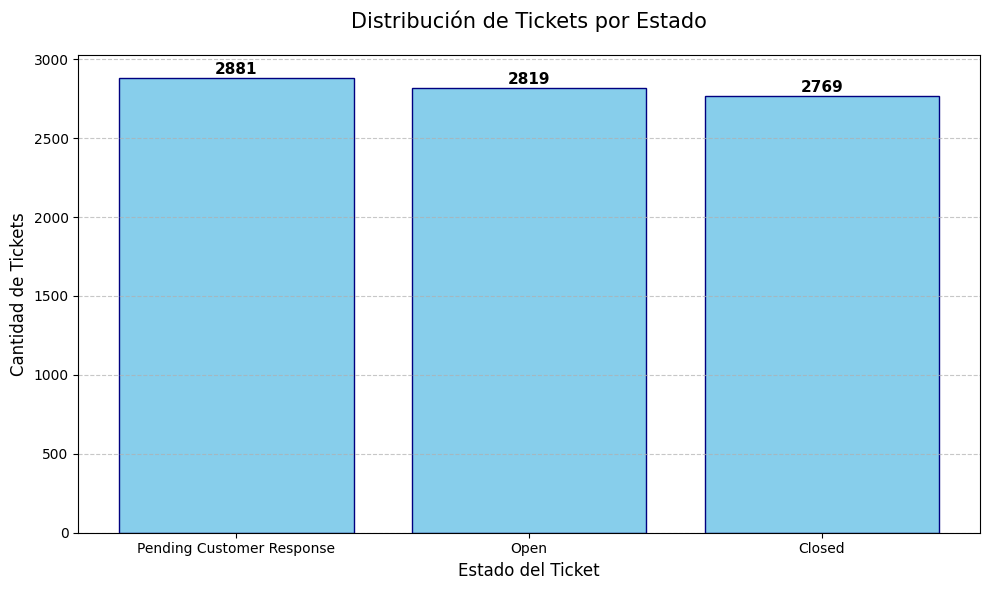

In [76]:
import matplotlib.pyplot as plt

# 1. Convertir a Pandas y ORDENAR por total (se ve mejor)
pd_result = result.toPandas().sort_values('total', ascending=False)

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# 3. Crear el gráfico de barras
bars = plt.bar(pd_result['status'], pd_result['total'], color='skyblue', edgecolor='navy')

# 4. Agregar etiquetas de datos sobre cada barra (los números exactos)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Personalizar estética
plt.title('Distribución de Tickets por Estado', fontsize=15, pad=20)
plt.xlabel('Estado del Ticket', fontsize=12)
plt.ylabel('Cantidad de Tickets', fontsize=12)
plt.xticks(rotation=0) # Etiquetas horizontales para que se lean fácil
plt.grid(axis='y', linestyle='--', alpha=0.7) # Una grilla suave de fondo

# 6. Mostrar
plt.tight_layout()
plt.show()


Columnas disponibles: Index(['status', 'total'], dtype='str')
                      status  total
0  Pending Customer Response   2881
1                       Open   2819
2                     Closed   2769


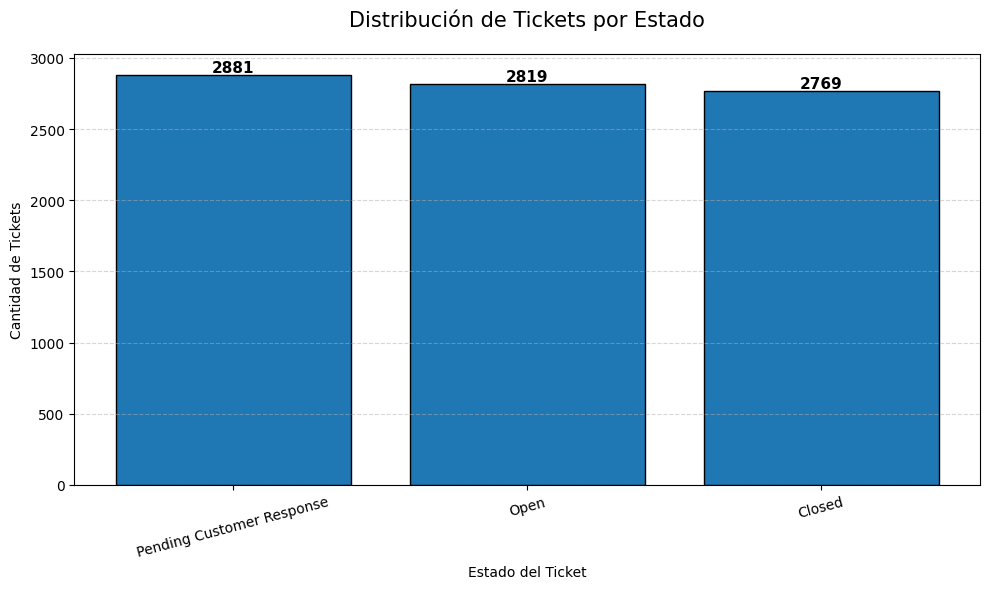

In [75]:
import matplotlib.pyplot as plt

# =========================
# 1. Convertir a Pandas
# =========================
pd_result = result.toPandas()

# =========================
# 2. Detectar columna correcta (robusto)
# =========================
if 'ticket_status' in pd_result.columns:
    status_col = 'ticket_status'
elif 'status' in pd_result.columns:
    status_col = 'status'
elif 'Ticket Status' in pd_result.columns:
    status_col = 'Ticket Status'
else:
    raise ValueError("❌ No se encontró columna de estado en el DataFrame")

# =========================
# 3. Ordenar
# =========================
pd_result = pd_result.sort_values('total', ascending=False)

# =========================
# 4. Validación pro (evita errores silenciosos)
# =========================
print("Columnas disponibles:", pd_result.columns)
print(pd_result)

# =========================
# 5. Plot
# =========================
plt.figure(figsize=(10, 6))

bars = plt.bar(
    pd_result[status_col],
    pd_result['total'],
    edgecolor='black'
)

# =========================
# 6. Etiquetas
# =========================
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        int(yval),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# =========================
# 7. Estética
# =========================
plt.title('Distribución de Tickets por Estado', fontsize=15, pad=20)
plt.xlabel('Estado del Ticket')
plt.ylabel('Cantidad de Tickets')

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# =========================
# 8. Mostrar
# =========================
plt.tight_layout()
plt.show()

In [74]:
df.select("Ticket Status").distinct().show()

+--------------------+
|       Ticket Status|
+--------------------+
|Pending Customer ...|
|                Open|
|              Closed|
+--------------------+



In [70]:
from pyspark.sql.functions import count

result = df.groupBy("Ticket Status").agg(
    count("*").alias("total")
)

In [71]:
df.createOrReplaceTempView("tickets")

result = spark.sql("""
    SELECT `Ticket Status` as status, COUNT(*) as total
    FROM tickets
    GROUP BY `Ticket Status`
""")

# Ahora el gráfico no tendrá KeyError porque 'status' existe como alias
pd_result = result.toPandas()


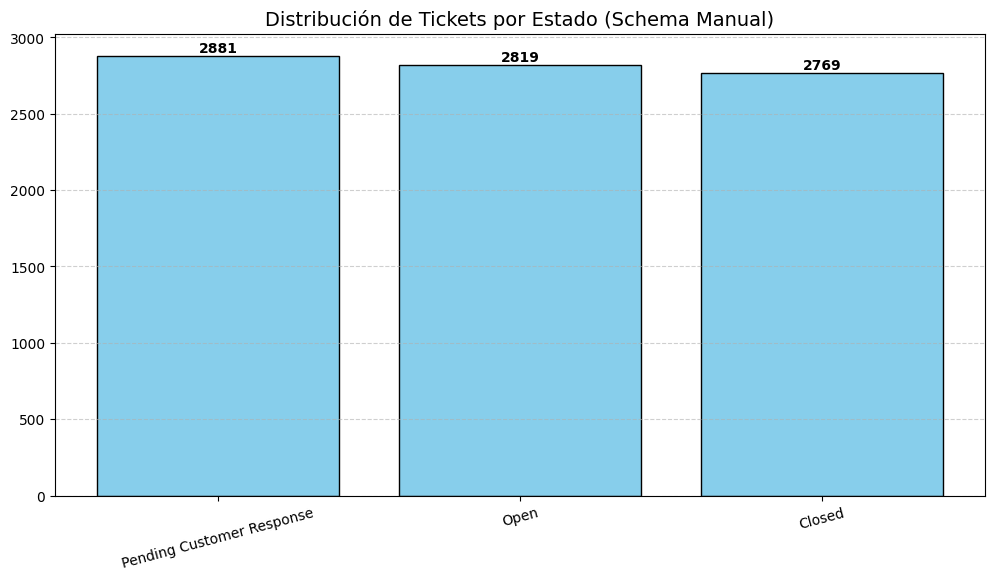

Total de registros procesados: 8469


In [72]:
# 1. SQL corregido usando comillas invertidas para los espacios
result = spark.sql("""
    SELECT 
        `Ticket Status` AS status, 
        COUNT(*) AS total
    FROM tickets
    WHERE `Ticket Status` IN ('Open', 'Closed', 'Pending Customer Response')
    GROUP BY `Ticket Status`
""")

# 2. Convertir a Pandas y ordenar
pd_result = result.toPandas().sort_values('total', ascending=False)

# 3. Gráfico profesional
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
bars = plt.bar(pd_result['status'], pd_result['total'], color='skyblue', edgecolor='black')

# Etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Distribución de Tickets por Estado (Schema Manual)', fontsize=14)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 4. Verificación de filas totales (por fin veremos si son 700 o 8000)
print(f"Total de registros procesados: {pd_result['total'].sum()}")
